In [1]:
import oqupy
import oqupy.operators as op
import numpy as np
from oqupy.iTEBD_TEMPO_useoqupybath import iTEBD_TEMPO_oqupy
from oqupy.process_tensor import TTInvariantProcessTensor
from oqupy.tti_tempo import TTITempo
from oqupy.tti_tempo import TTITempoCounting
import matplotlib.pyplot as plt


from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from scipy.optimize import minimize,Bounds

pt_parameters = {'tmax':50,
                 'steps':100, 
                 'dkmax':50,
                 'epsrel':10**(-6),
                 'alpha':0.1,
                 'omega_cutoff':1,                 
                 'temp':0.131}

omega_cutoff = pt_parameters['omega_cutoff']
alpha = pt_parameters['alpha']
temperature = pt_parameters['temp']
epsrel = pt_parameters['epsrel']
t_max = pt_parameters['tmax']
# dt = 1./omega_cutoff/np.sqrt(3)
num_steps = pt_parameters['steps']
dt = t_max/num_steps
dkmax = pt_parameters['dkmax']

t_list = np.linspace(0,t_max,num_steps+1)

tcut=50

Rho_0=oqupy.operators.spin_dm('x+')

# spectral density (without cutoff)
def j(w):
    return 2*alpha*w


In [2]:
correlations = oqupy.PowerLawSD(alpha=alpha,
                                zeta=1,
                                cutoff=omega_cutoff,
                                cutoff_type='exponential',
                                temperature=temperature)
bath = oqupy.Bath(op.sigma("z")/2.0, correlations)

In [3]:
num_steps=250
u=0.01
correlationscf=oqupy.bath_correlations.CustomCountingSD(j_function=j,cutoff=omega_cutoff,u=u,
                                                 cutoff_type='exponential',temperature=temperature)

bathcf = oqupy.Bath(op.sigma("z")/2.0, correlationscf)

In [4]:
import dill
from numpy import load

with open('results/processtensors/processtensor_fine_simplemodel_0.2ps_8', 'rb') as f:
    # The protocol version used is detected automatically, so we do not
    # have to specify it.
    processtensor = dill.load(f)

with open('results/processtensors/processtensor_fine_simplemodel_0.2ps_8', 'rb') as f:
    # The protocol version used is detected automatically, so we do not
    # have to specify it.
    processtensorCF = dill.load(f)

with open('bathcorrelations_100ps', 'rb') as f:
    # The protocol version used is detected automatically, so we do not
    # have to specify it.
    bath_corr = dill.load(f)

file_name1='results/zero_control_0.2ps_8/{0}ps/optimization_simplemodel_{0}ps'.format(1000)
with open(file_name1, 'rb') as f:
    # The protocol version used is detected automatically, so we do not
    # have to specify it.
    opt_dict= dill.load(f)

In [5]:
from scipy.interpolate import interp1d
#processtensor.length=100
opt_control=opt_dict['result'].x
delta_t = interp1d(np.linspace(0,t_prot,len(opt_control)),opt_control)
def hamiltonian_t(t):
    return delta_t(t)*oqupy.operators.sigma("x")/2

system = oqupy.TimeDependentSystem(hamiltonian_t)

bath_corr = oqupy.bath_dynamics.TwoTimeBathCorrelations(system, bath, processtensor, Rho_0)

NameError: name 't_prot' is not defined

In [6]:
plt.plot(np.linspace(0,t_prot,2*len(opt_control)),delta_t(np.linspace(0,t_prot,2*len(opt_control))))

NameError: name 't_prot' is not defined

NameError: name 'system' is not defined

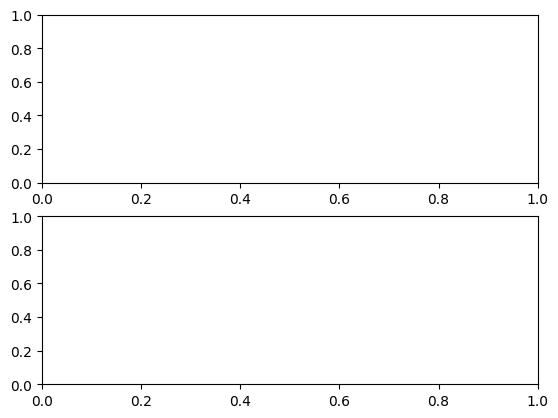

In [7]:
fig,axs=plt.subplots(2)

num_steps=int(100/0.2)

# compute dynamics
u=0.01
dynamics=oqupy.compute_dynamics(
process_tensor=processtensor,        
system=system,
initial_state=Rho_0,
start_time=0,
num_steps=num_steps)
t, s_x = dynamics.expectations(op.sigma('x'), real=True)

# compute heats

dynamicscf = oqupy.compute_dynamics(
process_tensor=processtensorCF,        
system=system,
initial_state=Rho_0,
start_time=0,
num_steps=num_steps)

In [8]:



import matplotlib.pyplot as plt  # Import AFTER setting backend

u = 0.01
heats = dynamicscf.states.trace(axis1=1, axis2=2).imag / u

fig, axs = plt.subplots(2, 1, figsize=(8, 6))  # Make sure fig and axs are defined

axs[0].plot(t, heats, label=t_prot)
axs[0].set_xlabel(r'$t$')
axs[0].set_ylabel(r'$\langle Q \rangle$')

axs[1].plot(t, s_x)
axs[1].set_xlabel(r'$t$')
axs[1].set_ylabel(r'$\langle \sigma_x \rangle$')

fig.legend()
plt.tight_layout()
plt.show()  # Use plt.show() instead of fig.show()


NameError: name 'dynamicscf' is not defined

(9, 401)


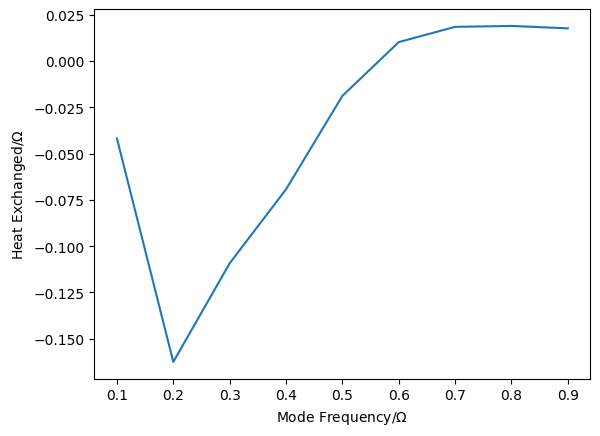

In [9]:
heat_list_osc_f = []
heat_list_osc=[]
processtensor.length=num_steps
freq_list = np.arange(0.1, 1, 0.1)
for w in freq_list:
    tlist, occ = bath_corr.occupation(w, 0.1,True)
    heat_list_osc_f.append((w * occ)/0.1)
    heat_list_osc.append(w * occ[-1]/0.1)
plt.plot(freq_list, heat_list_osc)
plt.xlabel(r"Mode Frequency$/\Omega$")
plt.ylabel(r"Heat Exchanged$/\Omega$")
print(np.shape(heat_list_osc_f))

In [10]:
heat_list = []
heat_list_f =[]
freq_list = np.arange(0.01, 100, 0.01)
for w in freq_list:
    tlist, occ = bath_corrs.occupation(w, 0.01, True)
    sel = tlist > (tlist[-1] - 2 * np.pi/w)
    sel2 = tlist > (tlist - 2 * np.pi/w)
    energy = occ * w
    period_averaged_energy = np.mean(energy[sel])
    heat_list.append(period_averaged_energy)
    heat_list_f.append(np.mean(energy[sel2]))
plt.plot(freq_list, heat_list)
plt.xlabel(r"Mode Frequency$/\Omega$")
plt.ylabel(r"Heat Exchanged$/\Omega$")

NameError: name 'bath_corrs' is not defined

In [11]:
import numpy as np
import matplotlib.pyplot as plt
freq_list = np.arange(0.1, 5000, 0.1)

plt.plot(freq_list, data)
plt.xlabel(r"Mode Frequency$/\Omega$")
plt.ylabel(r"Bath displacements$/\Omega$")
print(np.shape(heat_list_osc_f))

NameError: name 'data' is not defined

In [12]:
tlist,occ=bath_corrs.occupation(1,0.1,change_only=True)
plt.plot(tlist,occ)

NameError: name 'bath_corrs' is not defined

In [17]:
dw=0.01
freq_list = np.arange(dw, 1, dw)
occ_freq_t=np.zeros((len(tlist),len(freq_list)))
heat_freq_t=np.zeros((len(tlist),len(freq_list)))

processtensor.length=num_steps

for i,w in enumerate(freq_list):
    tlist,occ=bath_corr.occupation(w,dw,change_only=True)
    for j,t in enumerate(tlist):
        occ_freq_t[j][i]=occ[j]
        heat_freq_t[j][i]=w*occ[j]

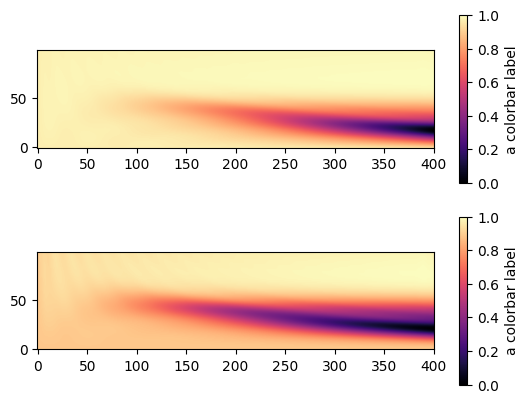

In [ ]:
import matplotlib as mpl
fig,axs=plt.subplots(2)


axs[0].imshow(occ_freq_t.T,cmap='magma',origin='lower')
axs[1].imshow(heat_freq_t.T,cmap='magma',origin='lower')
cmap = mpl.cm.cool
norm = mpl.colors.Normalize(vmin=5, vmax=5)

fig.colorbar(mpl.cm.ScalarMappable( cmap='magma'),
             ax=axs[0], orientation='vertical', label='a colorbar label')

fig.colorbar(mpl.cm.ScalarMappable(cmap='magma'),
             ax=axs[1], orientation='vertical', label='a colorbar label')
plt.show()

/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_78010/3553666247.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


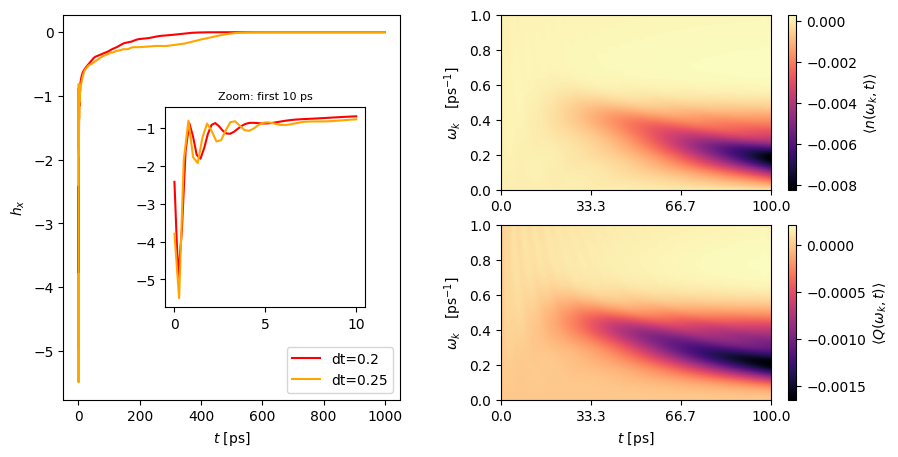

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
import dill  # assuming you're using dill to load your data
import matplotlib.gridspec as gridspec

# Load your data
t_prot = 1000  # or your actual protocol duration

with open(f'results/zero_control_0.2ps_8/{t_prot}ps/optimization_simplemodel_{t_prot}ps', 'rb') as f:
    control_2 = dill.load(f)

with open(f'results/zero_control/{t_prot}ps/optimization_simplemodel_{t_prot}ps', 'rb') as f:
    control_25 = dill.load(f)

# Create figure and GridSpec layout
fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1], height_ratios=[1, 1], wspace=0.3, hspace=0.2)

# Line plot with inset (left, spans both rows)
ax_main = fig.add_subplot(gs[:, 0])
ax_main.plot(np.linspace(0, 1000, int(1000 / 0.2)), control_2['result'].x, label='dt=0.2',c='r')
ax_main.plot(np.linspace(0, 1000, int(1000 / 0.25)), control_25['result'].x, label='dt=0.25',c='orange')
ax_main.set_xlabel(r"$t$ [ps]")
ax_main.set_ylabel(r"$h_x$")
ax_main.legend()

# Inset
inset_ax = inset_axes(
    ax_main,
    width=2,  # inches
    height=2,
    loc='center',
    bbox_to_anchor=(0.6, 0.5),
    bbox_transform=ax_main.transAxes,
    borderpad=0.5
)

inset_time = 10
inset_steps_2 = int(inset_time / 0.2)
inset_steps_25 = int(inset_time / 0.25)
inset_ax.plot(np.linspace(0, inset_time, inset_steps_2), control_2['result'].x[:inset_steps_2],c='red')
inset_ax.plot(np.linspace(0, inset_time, inset_steps_25), control_25['result'].x[:inset_steps_25],c='orange')
inset_ax.set_title("Zoom: first 10 ps", fontsize=8)

# Top heatmap (right)
ax1 = fig.add_subplot(gs[0, 1])
im1 = ax1.imshow(occ_freq_t.T, cmap='magma', origin='lower', aspect='auto',extent=[0,100,0,1])
fig.colorbar(im1, ax=ax1, orientation='vertical', label=r"$\langle n( \omega_k,t) \rangle$")

# Bottom heatmap (right)
ax2 = fig.add_subplot(gs[1, 1])
im2 = ax2.imshow(heat_freq_t.T, cmap='magma', origin='lower', aspect='auto',extent=[0,100,0,1])
fig.colorbar(im2, ax=ax2, orientation='vertical', label=r"$\langle Q( \omega_k,t) \rangle$")


ax1.set_ylabel(r"$\omega_k \quad [\text{ps}^{-1}]$")
ax2.set_ylabel(r"$\omega_k \quad [\text{ps}^{-1}]$")
ax2.set_xlabel(r"$t$ [ps]")

ax2.set_xticks(np.linspace(0,tlist[-1],4))
ax1.set_xticks(np.linspace(0,tlist[-1],4))

plt.tight_layout()
plt.show()
